# Trajectory Inference for Three Slices of the Mouse Thymus Dataset

## Loading Packages

In [1]:
import warnings
warnings.filterwarnings('ignore')

import scanpy as sc
import numpy as np

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

## Loading Data

In [2]:
def load_data(replicate):
    """
    Load data from files for each replicate and store them in a dictionary.
    
    Parameters:
    - replicate: list of strings, the replicate identifiers.
    
    Returns:
    - adata_analysis: dictionary, where keys are replicate identifiers and values are AnnData objects.
    """
    adata_analysis = {}
    for rep in replicate:
        file_path = f'../../../Mouse_Thymus_Replicate{rep}.h5ad'
        adata_analysis[f'replicate_{rep}'] = sc.read_h5ad(file_path)
    return adata_analysis

replicate = ['1', '2', '3']
adata_analysis = load_data(replicate)

## Calculating UMAP

In [3]:
def calculate_umap(adata, methods):
    """
    Calculate UMAP for each method and store the results in the AnnData object.
    
    Parameters:
    - adata: AnnData object, the data to process.
    - methods: list of strings, the methods to calculate UMAP for.
    """
    for method in methods:
        if method in adata.obsm:
            print(method)
            sc.pp.neighbors(adata, use_rep=method)
            # print(" run1")
            sc.tl.umap(adata, min_dist=0.5, spread=0.5)
            # print(" run2")
            adata.obsm[f'{method}_UMAP'] = adata.obsm['X_umap']
            # print(" run3")
            del adata.obsm['X_umap']
        else:
            print(f"Method '{method}' not found in obsm.")

methods_analysis = ['SpatialCOC', 'SpatialGlue', 'Seurat', 'STAGATE']

## Calculating Centroids

In [4]:
def calculate_centroids(adata, methods):
    """
    Calculate centroids for each cluster of each method.
    
    Parameters:
    - adata: AnnData object, the data to process.
    - methods: list of strings, the methods to calculate centroids for.
    
    Returns:
    - centroids_dict: dictionary, where keys are method names and values are dictionaries of centroids.
    """
    centroids_dict = {}
    for method in methods:
        umap_key = f'{method}_UMAP'
        if umap_key in adata.obsm:
            unique_clusters = np.unique(adata.obs[method])
            centroids = {}
            for cluster in unique_clusters:
                umap_coords = adata[adata.obs[method] == cluster].obsm[umap_key]
                centroid = np.mean(umap_coords, axis=0)
                centroids[cluster] = centroid
            centroids_dict[method] = centroids
        else:
            print(f"UMAP for method '{method}' not found in obsm.")
            centroids_dict[method] = None
    return centroids_dict

## PAGA Analysis

In [5]:
def perform_paga(adata, methods):
    """
    Perform PAGA for each method and store the results in the AnnData object.
    
    Parameters:
    - adata: AnnData object, the data to process.
    - methods: list of tuples, where each tuple contains the cluster key and the embedding key.
    """
    for cluster_key, embed_key in methods:
        sc.pp.neighbors(
            adata, 
            use_rep=embed_key, 
            key_added=f'neighbors_{cluster_key}', 
            n_neighbors=50
        )
        sc.tl.paga(
            adata,
            groups=cluster_key,
            neighbors_key=f'neighbors_{cluster_key}'
        )
        adata.uns[f'paga_{cluster_key}'] = adata.uns['paga'].copy()

methods = [
    ('SpatialCOC', 'SpatialCOC'),
    ('SpatialGlue', 'SpatialGlue'),
    ('Seurat', 'Seurat'),
    ('STAGATE', 'STAGATE'),
]

## Ploting Function

In [6]:
def plot_umap_with_centroids(adata, methods, replicate, paga_thresholds, colors_by_replicate_and_method):
    """
    Plot UMAP with centroids and PAGA connections for each method in the given replicate.

    Parameters:
    adata (AnnData): The AnnData object containing the data.
    methods (list): A list of tuples, where each tuple contains the cluster key and embed key for a method.
    replicate (str): The current replicate being processed.
    paga_thresholds (dict): A dictionary where keys are method names and values are the corresponding PAGA thresholds.
    colors_by_replicate_and_method (dict): A dictionary where keys are replicate numbers, and values are dictionaries with method names as keys and color lists as values.
    """
    all_connects = {}
    for cluster_key, embed_key in methods:
        print(cluster_key)
        umap_key = f'{embed_key}_UMAP'
        if umap_key not in adata.obsm or cluster_key not in adata.obs:
            print(f"Skipping {cluster_key} - data not found")
            continue
        
        # Get the color list corresponding to the current replicate and method
        colors = colors_by_replicate_and_method[replicate][cluster_key]
        
        unique_clusters = np.unique(adata.obs[cluster_key])
        centroids = {
            cluster: np.mean(adata[adata.obs[cluster_key] == cluster].obsm[umap_key], axis=0)
            for cluster in unique_clusters
        }
        print(f"Plot for {cluster_key} in replicate {replicate}:")
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.scatter(
            adata.obsm[umap_key][:, 0],
            adata.obsm[umap_key][:, 1],
            c=[colors[int(x) % len(colors)] for x in adata.obs[cluster_key]],
            s=100,
            alpha=0.7
        )
        
        # Plot centroids
        for cluster, centroid in centroids.items():
            ax.scatter(centroid[0], centroid[1], marker='o', color='black', s=800)
        
        # Plot PAGA connections
        paga_key = f'paga_{cluster_key}'
        if paga_key in adata.uns:
            connectivities = adata.uns[paga_key]['connectivities'].toarray()
            all_connects[cluster_key] = connectivities
            cluster_indices = {cluster: i for i, cluster in enumerate(unique_clusters)}
            print(f" {paga_key=} {connectivities.shape=}")
            threshold = paga_thresholds.get(cluster_key, 0.1)
            for i in range(len(unique_clusters)):
                for j in range(i + 1, len(unique_clusters)):
                    if connectivities[i, j] > threshold:
                        start = centroids[unique_clusters[i]]
                        end = centroids[unique_clusters[j]]
                        linewidth = 2 + 8 * connectivities[i, j]
                        ax.plot([start[0], end[0]], [start[1], end[1]], 
                               color='black', linewidth=linewidth, alpha=1)
        
        # Remove axis labels, ticks, and grid
        ax.set_title(f'')
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(False)
        
        # Save and show the plot
        plt.tight_layout()
        # plt.savefig(f'{cluster_key}_rep_{replicate}.png', dpi=500)
        # plt.savefig(f'{cluster_key}_rep_{replicate}.eps')
        plt.show()
    return all_connects

## Running

Processing replicate 1
SpatialCOC
SpatialGlue
Seurat
STAGATE
SpatialCOC
Plot for SpatialCOC in replicate 1:
 paga_key='paga_SpatialCOC' connectivities.shape=(7, 7)


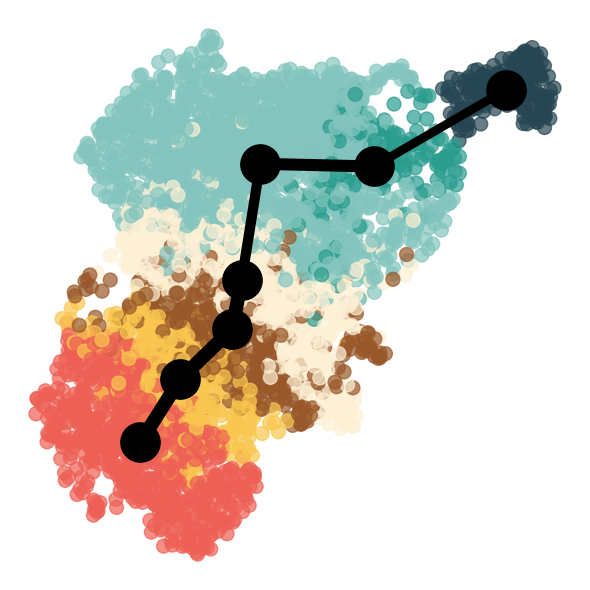

SpatialGlue
Plot for SpatialGlue in replicate 1:
 paga_key='paga_SpatialGlue' connectivities.shape=(7, 7)


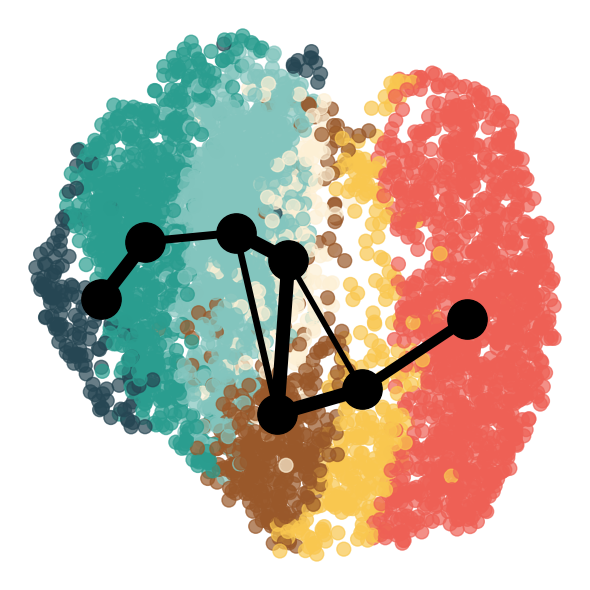

Seurat
Plot for Seurat in replicate 1:
 paga_key='paga_Seurat' connectivities.shape=(7, 7)


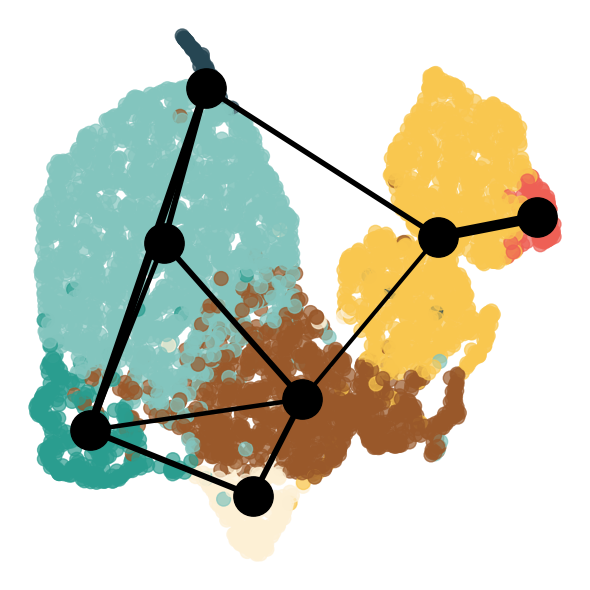

STAGATE
Plot for STAGATE in replicate 1:
 paga_key='paga_STAGATE' connectivities.shape=(7, 7)


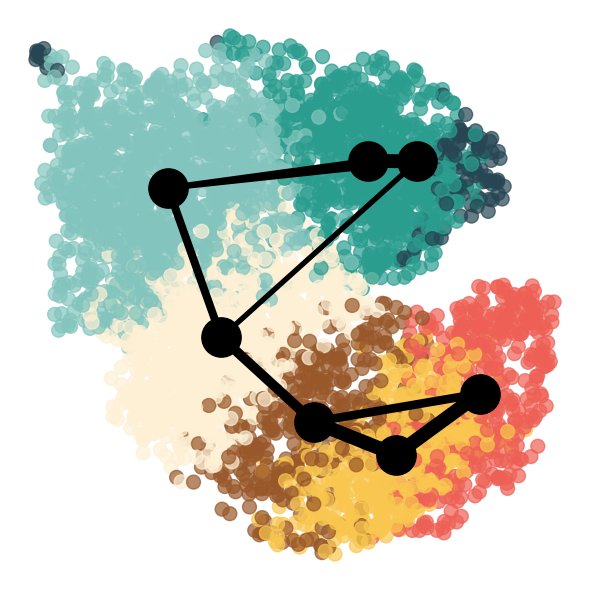

Processing replicate 2
SpatialCOC
SpatialGlue
Seurat
STAGATE
SpatialCOC
Plot for SpatialCOC in replicate 2:
 paga_key='paga_SpatialCOC' connectivities.shape=(7, 7)


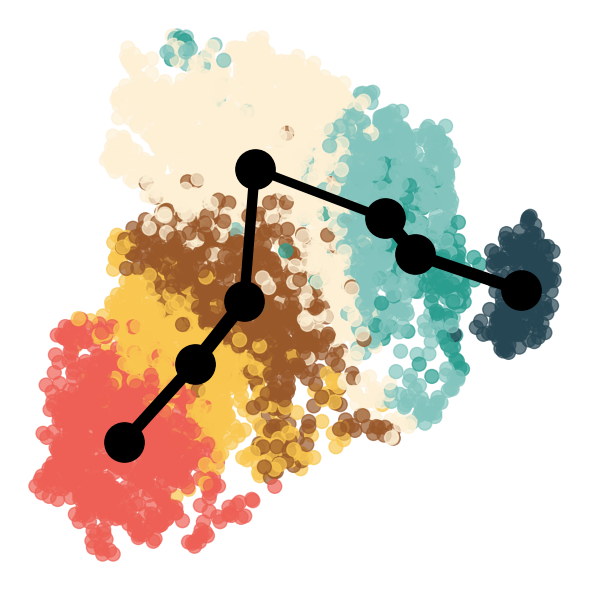

SpatialGlue
Plot for SpatialGlue in replicate 2:
 paga_key='paga_SpatialGlue' connectivities.shape=(7, 7)


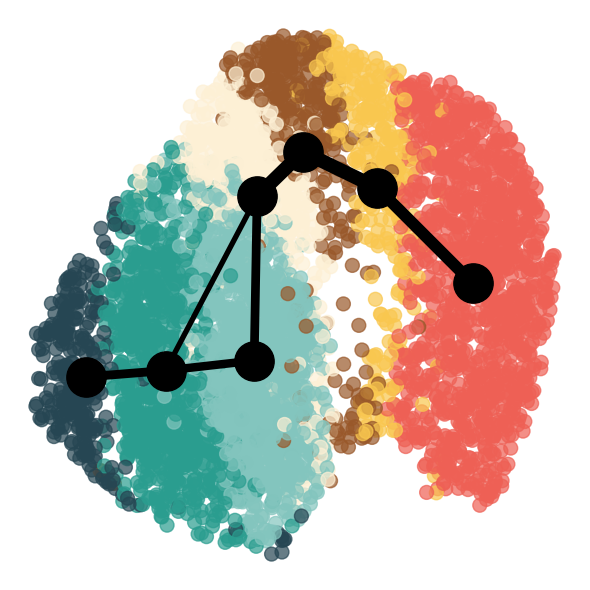

Seurat
Plot for Seurat in replicate 2:
 paga_key='paga_Seurat' connectivities.shape=(7, 7)


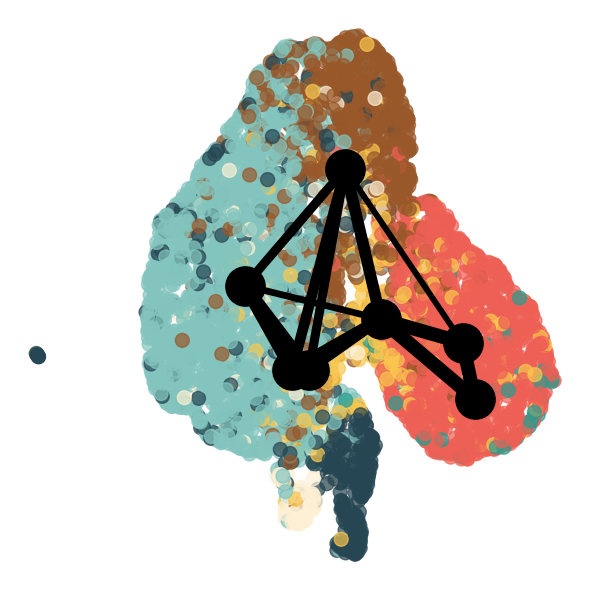

STAGATE
Plot for STAGATE in replicate 2:
 paga_key='paga_STAGATE' connectivities.shape=(7, 7)


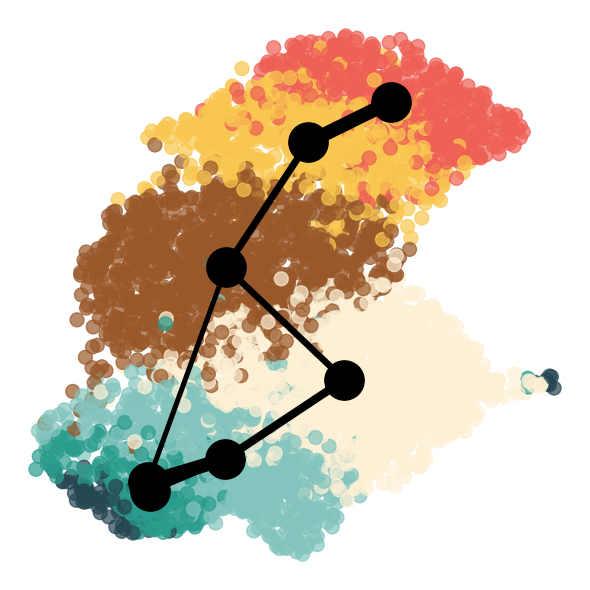

Processing replicate 3
SpatialCOC
SpatialGlue
Seurat
STAGATE
SpatialCOC
Plot for SpatialCOC in replicate 3:
 paga_key='paga_SpatialCOC' connectivities.shape=(7, 7)


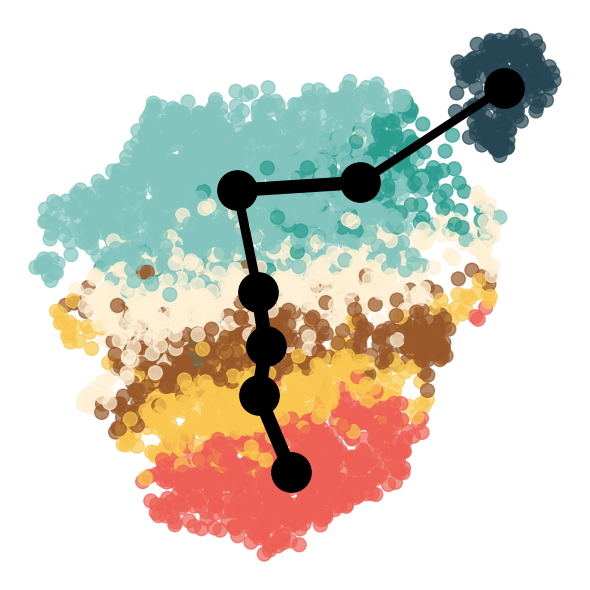

SpatialGlue
Plot for SpatialGlue in replicate 3:
 paga_key='paga_SpatialGlue' connectivities.shape=(7, 7)


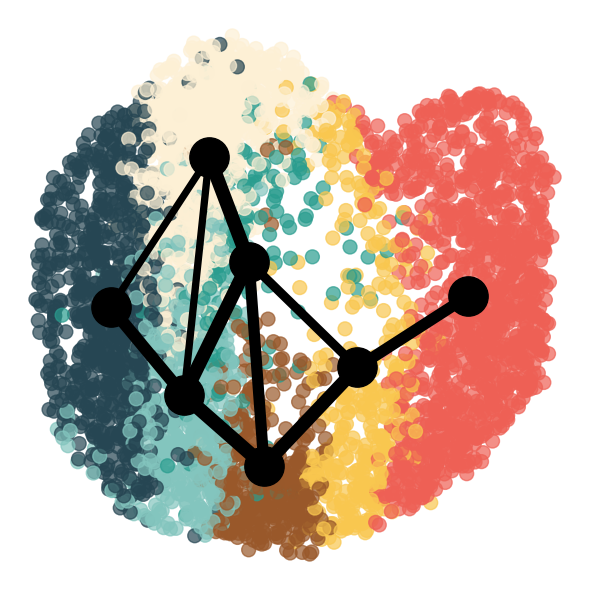

Seurat
Plot for Seurat in replicate 3:
 paga_key='paga_Seurat' connectivities.shape=(7, 7)


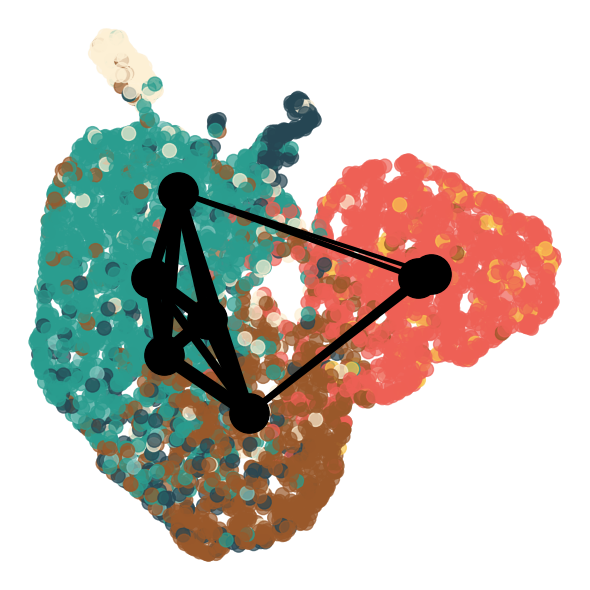

STAGATE
Plot for STAGATE in replicate 3:
 paga_key='paga_STAGATE' connectivities.shape=(7, 7)


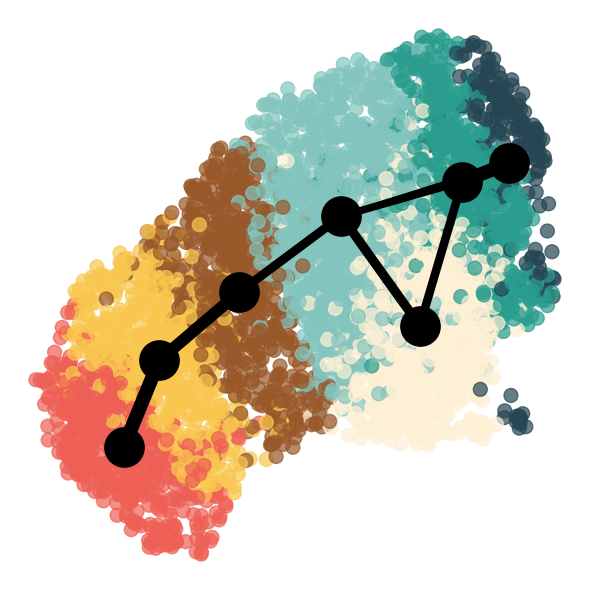

In [7]:
colors_by_replicate_and_method = {
    # Replicate 1
    '1': {
        'SpatialCOC':  ['#fdf0d5', '#264653', '#83c5be', '#2a9d8f', '#f9c74f', '#99582a', '#ee6055'],
        'SpatialGlue': ['#f9c74f', '#83c5be', '#2a9d8f', '#fdf0d5', '#264653', '#ee6055', '#99582a'],
        'Seurat':      ['#83c5be', '#f9c74f', '#99582a', '#2a9d8f', '#fdf0d5', '#ee6055', '#264653'],
        'STAGATE':     ['#99582a', '#2a9d8f', '#83c5be', '#fdf0d5', '#264653', '#f9c74f', '#ee6055'],
    },
    # Replicate 2
    '2': {
        'SpatialCOC':  ['#264653', '#ee6055', '#83c5be', '#99582a', '#fdf0d5', '#2a9d8f', '#f9c74f'],
        'SpatialGlue': ['#264653', '#fdf0d5', '#99582a', '#f9c74f', '#83c5be', '#ee6055', '#2a9d8f'],
        'Seurat':      ['#83c5be', '#ee6055', '#99582a', '#264653', '#f9c74f', '#fdf0d5', '#2a9d8f'],
        'STAGATE':     ['#fdf0d5', '#99582a', '#f9c74f', '#2a9d8f', '#83c5be', '#264653', '#ee6055'],
    },
    # Replicate 3
    '3': {
        'SpatialCOC':  ['#264653', '#ee6055', '#99582a', '#f9c74f', '#83c5be', '#fdf0d5', '#2a9d8f'],
        'SpatialGlue': ['#f9c74f', '#99582a', '#fdf0d5', '#2a9d8f', '#83c5be', '#ee6055', '#264653'],
        'Seurat':      ['#2a9d8f', '#ee6055', '#99582a', '#264653', '#fdf0d5', '#f9c74f', '#83c5be'],
        'STAGATE':     ['#264653', '#2a9d8f', '#ee6055', '#fdf0d5', '#83c5be', '#99582a', '#f9c74f'],
    },
}

# Set PAGA thresholds for each method
paga_thresholds = {
    'SpatialCOC': 0.45,
    'SpatialGlue': 0.2,
    'Seurat': 0.1,
    'STAGATE': 0.2
}

graphs = {}
# Run
for rep in replicate:
    print(f"Processing replicate {rep}")
    adata = adata_analysis[f'replicate_{rep}']
    # print("run")
    calculate_umap(adata, methods_analysis)
    # print("run2")
    centroids_dict = calculate_centroids(adata, methods_analysis)
    # print("run3")
    perform_paga(adata, methods)
    # print("run4")
    all_connects = plot_umap_with_centroids(
        adata, 
        methods, 
        rep, 
        paga_thresholds, 
        colors_by_replicate_and_method
    )
    graphs[rep] = all_connects

## Saving Results

In [8]:
def save_umap_clustering_to_excel(adata_dict, output_path):
    """
    Save UMAP coordinates and clustering results to Excel file

    Parameters:
    adata_dict: Dictionary with replicate names as keys and AnnData objects as values
    output_path: Path to save the Excel file
    """
    with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
        for replicate_name, adata in adata_dict.items():
            print(f"Processing {replicate_name}...")

            # Dictionary to store data for each method
            data_to_save = {}

            # Define mapping between UMAP coordinates and clustering labels
            pairs = [
                ('SpatialCOC_UMAP', 'SpatialCOC'),
                ('SpatialGlue_UMAP', 'SpatialGlue'),
                ('Seurat_UMAP', 'Seurat'),
                ('STAGATE_UMAP', 'STAGATE')
            ]

            # Extract UMAP coordinates and clustering labels for each method
            for umap_key, cluster_key in pairs:
                if umap_key in adata.obsm and cluster_key in adata.obs:
                    # Get UMAP coordinates
                    umap_data = adata.obsm[umap_key]

                    # Create DataFrame with UMAP coordinates and cluster labels
                    if umap_data.shape[1] >= 2:  # Ensure at least 2 dimensions
                        umap_df = pd.DataFrame(
                            umap_data[:, :2],  # Take first 2 UMAP dimensions
                            columns=[f'{umap_key}_1', f'{umap_key}_2']
                        )

                        # Add cluster labels
                        cluster_labels = adata.obs[cluster_key]
                        if isinstance(cluster_labels, pd.Series):
                            umap_df[cluster_key] = cluster_labels.values
                        else:
                            umap_df[cluster_key] = cluster_labels

                        # Set index to observation names
                        umap_df.index = adata.obs_names

                        data_to_save[f"{cluster_key}_data"] = umap_df

            # Combine all DataFrames for this replicate
            if data_to_save:
                # Start with the first DataFrame
                first_key = list(data_to_save.keys())[0]
                combined_df = data_to_save[first_key].copy()

                # Add columns from remaining DataFrames
                for key in list(data_to_save.keys())[1:]:
                    df = data_to_save[key]
                    for col in df.columns:
                        if col not in combined_df.columns:
                            combined_df[col] = df[col]

                # Write to Excel sheet
                sheet_name = replicate_name[:31]  # Truncate to 31 chars for Excel compatibility

                # Save DataFrame to Excel
                combined_df.to_excel(writer, sheet_name=sheet_name)

                print(f"  {replicate_name}: Saved {len(combined_df.columns)} columns")
            else:
                print(f"  {replicate_name}: No valid UMAP/clustering data found")

    print(f"\nResults saved to: {output_path}")

# save_umap_clustering_to_excel(adata_analysis, "umap_clustering_results.xlsx")

## Batch effect removal quantification


In [9]:
from scipy.spatial.distance import cosine
from itertools import permutations
import numpy as np

def graph_distance_with_permutation(adj1, adj2, permutation):
    """
    Calculate cosine distance between two adjacency matrices under a given permutation

    Parameters:
    - adj1: numpy array, first adjacency matrix
    - adj2: numpy array, second adjacency matrix
    - permutation: tuple, permutation to apply to adj2

    Returns:
    - distance: float, cosine distance between the two matrices
    """
    n = len(permutation)
    # Create permutation matrix from the permutation tuple
    perm_matrix = np.zeros((n, n))
    for i, j in enumerate(permutation):
        perm_matrix[i, j] = 1

    # Apply permutation to adj2: P * A * P^T
    adj2_permuted = perm_matrix @ adj2 @ perm_matrix.T

    # Flatten matrices and compute cosine distance
    vec1 = adj1.ravel()
    vec2 = adj2_permuted.ravel()

    return cosine(vec1, vec2)


def find_optimal_graph_matching(adj1, adj2):
    """
    Find optimal permutation that minimizes distance between two adjacency matrices

    Parameters:
    - adj1: numpy array, first adjacency matrix
    - adj2: numpy array, second adjacency matrix

    Returns:
    - best_permutation: tuple, permutation that gives minimum distance
    - min_distance: float, minimum distance achieved
    - all_distances: list, distances for all permutations
    """
    n = adj1.shape[0]
    identity = tuple(range(n))

    # Try all permutations (warning: factorial complexity!)
    all_perms = list(permutations(range(n)))
    min_distance = float('inf')
    best_permutation = identity
    all_distances = []

    for perm in all_perms:
        dist = graph_distance_with_permutation(adj1, adj2, perm)
        all_distances.append(dist)

        if dist < min_distance:
            min_distance = dist
            best_permutation = perm

    return best_permutation, min_distance, all_distances


def calculate_pairwise_graph_distances(graphs, methods):
    """
    Calculate pairwise distances between replicate graphs for each method

    Parameters:
    - graphs: dict, nested dictionary: graphs[replicate][method] = adjacency_matrix
    - methods: list, list of method names to analyze

    Returns:
    - results: dict, nested dictionary with distance results for each method and pair
    """
    replicates = sorted(graphs.keys())
    results = {}

    for method in methods:
        print(f"\n{'='*60}")
        print(f"Analyzing method: {method}")
        print(f"{'='*60}")

        method_results = {}

        # Compare each pair of replicates
        for i, rep1 in enumerate(replicates):
            for j, rep2 in enumerate(replicates):
                if i < j:  # Only compare each pair once
                    pair_key = f"Rep{rep1}_vs_Rep{rep2}"

                    adj1 = graphs[rep1][method]
                    adj2 = graphs[rep2][method]

                    print(f"\nComparing: Replicate {rep1} vs Replicate {rep2}")
                    print(f"Matrix 1 shape: {adj1.shape}, Matrix 2 shape: {adj2.shape}")

                    # Find optimal permutation
                    best_perm, min_dist, all_dists = find_optimal_graph_matching(adj1, adj2)

                    # Also compute unaligned distance (without permutation)
                    identity = tuple(range(adj1.shape[0]))
                    unaligned_dist = graph_distance_with_permutation(adj1, adj2, identity)

                    method_results[pair_key] = {
                        'best_permutation': best_perm,
                        'min_distance': min_dist,
                        'unaligned_distance': unaligned_dist,
                        'distance_reduction': unaligned_dist - min_dist,
                        'reduction_percentage': (unaligned_dist - min_dist) / unaligned_dist * 100 if unaligned_dist > 0 else 0
                    }

                    print(f"Best permutation: {best_perm}")
                    print(f"Minimum distance: {min_dist:.6f}")
                    # Optional detailed output:
                    # print(f"Unaligned distance: {unaligned_dist:.6f}")
                    # print(f"Distance reduction: {unaligned_dist - min_dist:.6f} ({(unaligned_dist - min_dist) / unaligned_dist * 100:.2f}%)")

        results[method] = method_results

    return results

In [10]:
methods_to_analyze = ['SpatialCOC', 'SpatialGlue', 'Seurat', 'STAGATE']
graph_matching_results = calculate_pairwise_graph_distances(graphs, methods_to_analyze)


Analyzing method: SpatialCOC

Comparing: Replicate 1 vs Replicate 2
Matrix 1 shape: (7, 7), Matrix 2 shape: (7, 7)
Best permutation: (6, 1, 4, 5, 2, 0, 3)
Minimum distance: 0.032015

Comparing: Replicate 1 vs Replicate 3
Matrix 1 shape: (7, 7), Matrix 2 shape: (7, 7)
Best permutation: (6, 3, 5, 2, 1, 0, 4)
Minimum distance: 0.007364

Comparing: Replicate 2 vs Replicate 3
Matrix 1 shape: (7, 7), Matrix 2 shape: (7, 7)
Best permutation: (0, 3, 1, 4, 5, 2, 6)
Minimum distance: 0.035020

Analyzing method: SpatialGlue

Comparing: Replicate 1 vs Replicate 2
Matrix 1 shape: (7, 7), Matrix 2 shape: (7, 7)
Best permutation: (3, 5, 0, 6, 4, 1, 2)
Minimum distance: 0.063992

Comparing: Replicate 1 vs Replicate 3
Matrix 1 shape: (7, 7), Matrix 2 shape: (7, 7)
Best permutation: (0, 6, 3, 4, 5, 2, 1)
Minimum distance: 0.125532

Comparing: Replicate 2 vs Replicate 3
Matrix 1 shape: (7, 7), Matrix 2 shape: (7, 7)
Best permutation: (3, 0, 6, 2, 4, 1, 5)
Minimum distance: 0.154660

Analyzing method: Se

In [11]:
import pandas as pd

# Create a summary table from the graph matching results
summary_data = []

for method in methods_to_analyze:
    for pair_key, pair_result in graph_matching_results[method].items():
        summary_data.append({
            'Method': method,
            'Replicate_Pair': pair_key,
            'Min_Distance': pair_result['min_distance'],
            'Unaligned_Distance': pair_result['unaligned_distance'],
            'Distance_Reduction': pair_result['distance_reduction'],
            'Reduction_Percentage(%)': pair_result['reduction_percentage']
        })

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*80)
print("GRAPH MATCHING RESULTS SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))

# Average minimum distances by method
print("\n" + "="*80)
print("AVERAGE MINIMUM DISTANCE BY METHOD (lower = more similar)")
print("="*80)
method_avg = summary_df.groupby('Method')['Min_Distance'].mean().sort_values()
for method, avg_dist in method_avg.items():
    print(f"{method:15s}: {avg_dist:.6f}")

# Average unaligned distances by method
print("\n" + "="*80)
print("AVERAGE UNALIGNED DISTANCE BY METHOD")
print("="*80)
method_avg_unaligned = summary_df.groupby('Method')['Unaligned_Distance'].mean().sort_values()
for method, avg_dist in method_avg_unaligned.items():
    print(f"{method:15s}: {avg_dist:.6f}")


GRAPH MATCHING RESULTS SUMMARY
     Method Replicate_Pair  Min_Distance  Unaligned_Distance  Distance_Reduction  Reduction_Percentage(%)
 SpatialCOC   Rep1_vs_Rep2      0.032015            0.705136            0.673121                95.459733
 SpatialCOC   Rep1_vs_Rep3      0.007364            0.328222            0.320858                97.756313
 SpatialCOC   Rep2_vs_Rep3      0.035020            0.697352            0.662332                94.978173
SpatialGlue   Rep1_vs_Rep2      0.063992            0.659802            0.595810                90.301322
SpatialGlue   Rep1_vs_Rep3      0.125532            0.541153            0.415620                76.802825
SpatialGlue   Rep2_vs_Rep3      0.154660            0.543575            0.388914                71.547533
     Seurat   Rep1_vs_Rep2      0.180691            0.599036            0.418345                69.836363
     Seurat   Rep1_vs_Rep3      0.150814            0.220010            0.069196                31.451407
     Seurat   

In [12]:
pivot_dist = (summary_df
              .pivot(index='Replicate_Pair', columns='Method', values='Min_Distance')
              .loc[['Rep1_vs_Rep2', 'Rep1_vs_Rep3', 'Rep2_vs_Rep3'],
                   ['SpatialCOC', 'SpatialGlue', 'Seurat', 'STAGATE']])

pivot_sim = 1 - pivot_dist
print(pivot_sim)

output_file = 'Cosine_Similarity.xlsx'
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    pivot_sim.to_excel(writer, sheet_name='Cosine_Similarity', index=True)

Method          SpatialCOC  SpatialGlue    Seurat   STAGATE
Replicate_Pair                                             
Rep1_vs_Rep2      0.967985     0.936008  0.819309  0.963164
Rep1_vs_Rep3      0.992636     0.874468  0.849186  0.943693
Rep2_vs_Rep3      0.964980     0.845340  0.925135  0.919335


## Boxplot: Graph Distance Distribution Across Methods


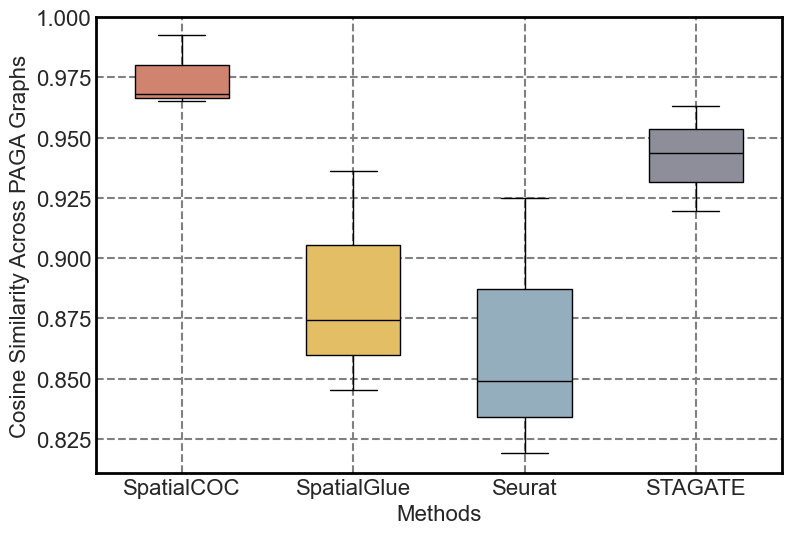

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------- 1. Load and prepare data ----------
df = pd.read_excel('Cosine_Similarity.xlsx')
methods_disp = ['SpatialCOC', 'SpatialGlue', 'Seurat', 'STAGATE']
colors       = ['#D0836F', '#E4BE64', '#94aebd', '#8D8E99']
plot_data    = [df[col].dropna().values for col in methods_disp]

# ---------- 2. Configure plot style ----------
fontsize = 16
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = fontsize
plt.rcParams['axes.edgecolor'] = 'black'

# ---------- 3. Set y-axis limits ----------
all_vals = np.concatenate(plot_data)
delta = 0.05 * (all_vals.max() - all_vals.min())
y_min, y_max = all_vals.min() - delta, all_vals.max() + delta

# ---------- 4. Create boxplot ----------
fig, ax = plt.subplots(figsize=(8, 5.3))
bp = ax.boxplot(plot_data, patch_artist=True,
                boxprops=dict(linewidth=1, edgecolor='black'),
                medianprops=dict(linewidth=1, color='black'),
                whiskerprops=dict(linewidth=1, color='black'),
                capprops=dict(linewidth=1, color='black'),
                widths=0.55, showfliers=False)

# Fill boxes with method-specific colors
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# ---------- 5. Configure axes labels and ticks ----------
ax.set_xticks(range(1, len(methods_disp)+1))
ax.set_xticklabels(methods_disp, fontsize=fontsize)
ax.set_xlabel('Methods', fontsize=fontsize)
ax.set_ylabel('Cosine Similarity Across PAGA Graphs', fontsize=fontsize)

# Set y-axis tick font size
ax.tick_params(axis='y', labelsize=fontsize)

ax.set_ylim(y_min, 1)

# Set spine width for all axes
for spine in ax.spines.values():
    spine.set_linewidth(2)

# Add grid lines for better readability
ax.grid(axis='y', color='gray', linestyle='--', alpha=1, zorder=-10, linewidth=1.5)
for x in range(1, len(methods_disp)+1):
    ax.axvline(x=x, color='gray', linestyle='--', alpha=1, zorder=-10, linewidth=1.5)

plt.tight_layout(pad=0.1, rect=[0.03, 0, 1, 0.98])
# plt.savefig('Cosine_Similarity_Boxplot.png', dpi=500)
# plt.savefig('Cosine_Similarity_Boxplot.eps')
plt.show()